<a href="https://colab.research.google.com/github/mar-olya/compling-Markovich/blob/main/%D0%9C%D0%B0%D1%80%D0%BA%D0%BE%D0%B2%D0%B8%D1%87_vectors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашка

1. Скачать [датасет по ссылке](https://raw.githubusercontent.com/tyqiangz/multilingual-sentiment-datasets/refs/heads/main/data/english/test.csv) (просто запустить строку ниже)

In [16]:
!wget https://raw.githubusercontent.com/tyqiangz/multilingual-sentiment-datasets/refs/heads/main/data/english/test.csv

--2025-11-03 18:07:07--  https://raw.githubusercontent.com/tyqiangz/multilingual-sentiment-datasets/refs/heads/main/data/english/test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 102826 (100K) [text/plain]
Saving to: ‘test.csv’

test.csv            100%[===================>] 100.42K  --.-KB/s    in 0.05s   

2025-11-03 18:07:07 (2.05 MB/s) - ‘test.csv’ saved [102826/102826]



2. Открыть csv и сохранить текст в переменную (макс. балл == 1)

In [17]:
import pandas as pd

# Открываем CSV файл
df = pd.read_csv('test.csv')

# Сохраняем текст в переменную (предполагая, что колонка с текстом называется 'text')
text_data = df['text']

3. Извлечь столбец с текстами (макс. балл == 1)

In [18]:
import pandas as pd

# Читаем CSV файл
df = pd.read_csv('test.csv')

# Извлекаем столбец с текстами
# Если название столбца известно (например 'text', 'review', 'comment' и т.д.)
texts = df['text']

print(f"Извлечено {len(texts)} текстов")
print("Первые 3 текста:")
for i, text in enumerate(texts.head(3)):
    print(f"{i+1}. {text}")

Извлечено 870 текстов
Первые 3 текста:
1. Trying to have a conversation with my dad about vegetarianism is the most pointless infuriating thing ever #caveman 
2. #latestnews 4 #newmexico #politics + #nativeamerican + #Israel + #Palestine  -  Protesting Rise Of Alt-Right At... 
3. @user You are a stand up guy and a Gentleman Vice President Pence 


4. Построить Bag-of-Words (макс. балл == 3)

=== Задача 1.1: Создание словаря и BoW ===
Размер словаря: 4028 слов
Создано 870 BoW векторов

=== Задача 1.2: Визуализация результатов ===
Топ-10 самых частых слов:
  user: 570
  the: 387
  to: 268
  a: 227
  of: 199
  is: 186
  for: 176
  in: 165
  and: 164
  i: 135


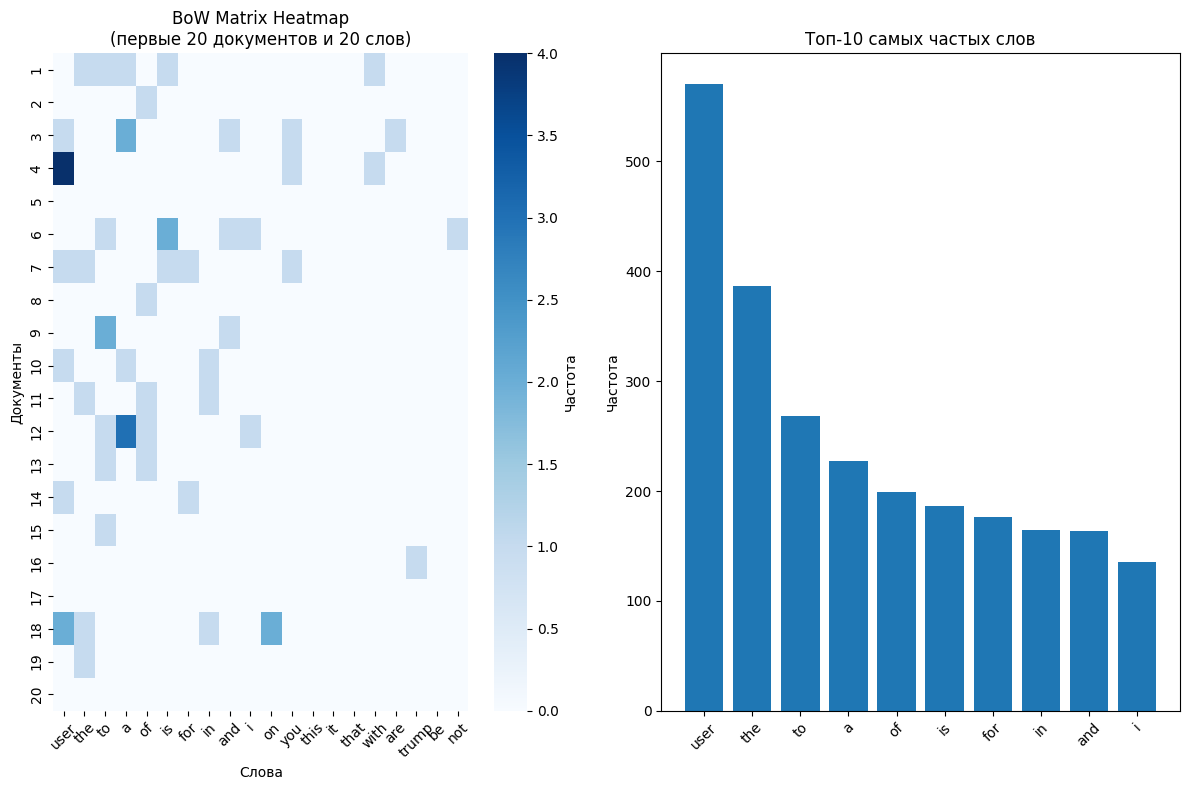


Общая статистика:
Всего документов: 870
Всего уникальных слов: 4028
Самое частое слово: 'user' встречается 570 раз

Пример BoW вектора для первого документа (первые 10 элементов):
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Соответствующие слова: ['trying', 'to', 'have', 'a', 'conversation', 'with', 'my', 'dad', 'about', 'vegetarianism']


In [19]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('test.csv')
texts = df['text'].tolist()

# Задача 1.1: Создание словаря и BoW представления
print("=== Задача 1.1: Создание словаря и BoW ===")

# Предобработка текстов
processed_texts = []
for text in texts:
    # Приведение к нижнему регистру и удаление знаков препинания
    clean_text = re.sub(r'[^\w\s]', '', str(text).lower())
    words = clean_text.split()
    processed_texts.append(words)

# Построение словаря
vocabulary = {}
word_index = 0
for text in processed_texts:
    for word in text:
        if word not in vocabulary:
            vocabulary[word] = word_index
            word_index += 1

print(f"Размер словаря: {len(vocabulary)} слов")

# Создание BoW векторов
bow_vectors = []
for text in processed_texts:
    vector = [0] * len(vocabulary)
    for word in text:
        if word in vocabulary:
            vector[vocabulary[word]] += 1
    bow_vectors.append(vector)

print(f"Создано {len(bow_vectors)} BoW векторов")

# Задача 1.2: Визуализация результатов
print("\n=== Задача 1.2: Визуализация результатов ===")

# Таблица частот слов
word_freq = Counter()
for text in processed_texts:
    word_freq.update(text)

print("Топ-10 самых частых слов:")
for word, freq in word_freq.most_common(10):
    print(f"  {word}: {freq}")

# Heatmap матрицы BoW (для первых 20 документов и 20 слов)
plt.figure(figsize=(12, 8))

# Создаем уменьшенную матрицу для визуализации
top_words = [word for word, _ in word_freq.most_common(20)]
top_word_indices = [vocabulary[word] for word in top_words]

# Берем первые 20 документов
bow_matrix_vis = []
for i in range(min(20, len(bow_vectors))):
    doc_vector = [bow_vectors[i][idx] for idx in top_word_indices]
    bow_matrix_vis.append(doc_vector)

# Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(bow_matrix_vis, xticklabels=top_words, yticklabels=range(1, 21),
            cmap='Blues', cbar_kws={'label': 'Частота'})
plt.title('BoW Matrix Heatmap\n(первые 20 документов и 20 слов)')
plt.xlabel('Слова')
plt.ylabel('Документы')
plt.xticks(rotation=45)

# График самых частых слов
plt.subplot(1, 2, 2)
top_10_words = word_freq.most_common(10)
words, freqs = zip(*top_10_words)
plt.bar(range(len(words)), freqs)
plt.title('Топ-10 самых частых слов')
plt.xticks(range(len(words)), words, rotation=45)
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

# Дополнительная информация
print(f"\nОбщая статистика:")
print(f"Всего документов: {len(texts)}")
print(f"Всего уникальных слов: {len(vocabulary)}")
print(f"Самое частое слово: '{word_freq.most_common(1)[0][0]}' встречается {word_freq.most_common(1)[0][1]} раз")

# Пример BoW вектора для первого документа
print(f"\nПример BoW вектора для первого документа (первые 10 элементов):")
print(bow_vectors[0][:10])
print("Соответствующие слова:", [list(vocabulary.keys())[list(vocabulary.values()).index(i)] for i in range(10)])

5. Построить TF-IDF (макс. балл == 5)



In [20]:
import pandas as pd
import re
from gensim import corpora, models

# Простая версия TF-IDF
df = pd.read_csv('test.csv')
texts = df['text'].tolist()

# Предобработка
processed_texts = [re.sub(r'[^\w\s]', '', str(text).lower()).split() for text in texts]

# Gensim TF-IDF
dictionary = corpora.Dictionary(processed_texts)
bow_corpus = [dictionary.doc2bow(text) for text in processed_texts]

tfidf_model = models.TfidfModel(bow_corpus)
tfidf_corpus = tfidf_model[bow_corpus]

# Сохраняем TF-IDF векторы
tfidf_data = []
for doc_id, doc_vector in enumerate(tfidf_corpus):
    for word_id, score in doc_vector:
        tfidf_data.append({
            'doc_id': doc_id,
            'word_id': word_id,
            'word': dictionary[word_id],
            'tfidf_score': score
        })

tfidf_df = pd.DataFrame(tfidf_data)
tfidf_df.to_csv('tfidf_simple.csv', index=False)
print("TF-IDF сохранен в 'tfidf_simple.csv'")

TF-IDF сохранен в 'tfidf_simple.csv'


##### **Как вычислить компоненты вручную**

```python
def analyze_tfidf_components(bow_corpus, dictionary):
    # Шаг 1: Создаем матрицу TF (term frequency)
    tf_matrix = np.zeros((len(bow_corpus), len(dictionary)))
    for doc_idx, doc in enumerate(bow_corpus):
        for word_idx, freq in doc:
            tf_matrix[doc_idx, word_idx] = freq
    
    # Шаг 2: Вычисляем DF (document frequency)
    df_vector = np.sum(tf_matrix > 0, axis=0)  # Количество документов с каждым словом
    
    # Шаг 3: Вычисляем IDF (inverse document frequency)
    N = len(bow_corpus)  # общее количество документов
    idf_vector = np.log(N / (df_vector + 1)) + 1
    
    # Шаг 4: Вычисляем TF-IDF вручную
    tfidf_manual = tf_matrix * idf_vector
    
    return tf_matrix, df_vector, idf_vector, tfidf_manual
```

6. Произвести сравните

*Эта часть не оценивается, но будет давать доп. баллы на экзамене для тех, кто выполнит её*

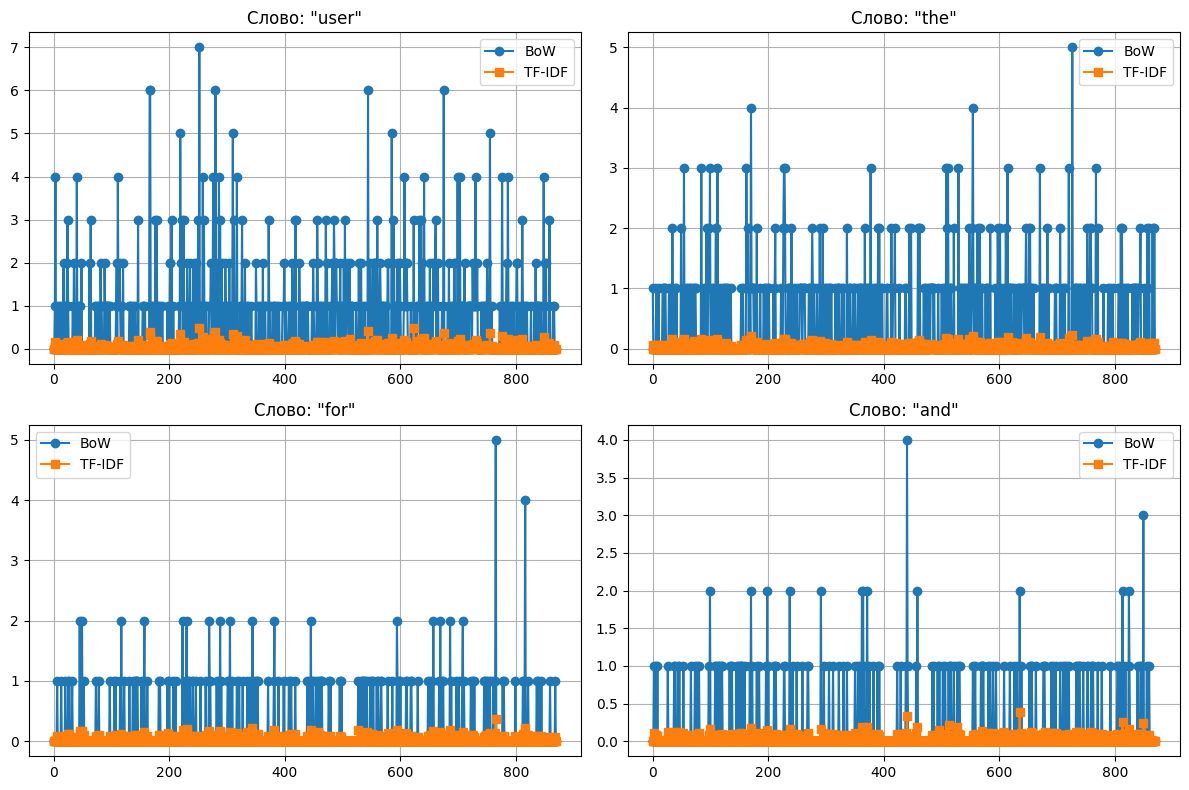

In [21]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from gensim import corpora, models

# Простая версия сравнения
df = pd.read_csv('test.csv')
texts = df['text'].tolist()

# Предобработка
processed_texts = [re.sub(r'[^\w\s]', '', str(text).lower()).split() for text in texts]

# Создаем модели
dictionary = corpora.Dictionary(processed_texts)
bow_corpus = [dictionary.doc2bow(text) for text in processed_texts]
tfidf_model = models.TfidfModel(bow_corpus)
tfidf_corpus = tfidf_model[bow_corpus]

# Автоматический выбор 4 частых слов
from collections import Counter
word_freq = Counter()
for text in processed_texts:
    word_freq.update(text)

selected_words = [word for word, freq in word_freq.most_common(10) if len(word) > 2][:4]

# Сравнение
plt.figure(figsize=(12, 8))
for i, word in enumerate(selected_words):
    if word in dictionary.token2id:
        word_id = dictionary.token2id[word]

        bow_weights = []
        tfidf_weights = []

        for doc_id in range(len(processed_texts)):
            bow_dict = dict(bow_corpus[doc_id])
            tfidf_dict = dict(tfidf_corpus[doc_id])

            bow_weights.append(bow_dict.get(word_id, 0))
            tfidf_weights.append(tfidf_dict.get(word_id, 0))

        plt.subplot(2, 2, i+1)
        plt.plot(bow_weights, label='BoW', marker='o')
        plt.plot(tfidf_weights, label='TF-IDF', marker='s')
        plt.title(f'Слово: "{word}"')
        plt.legend()
        plt.grid(True)

plt.tight_layout()
plt.show()

##### **Как построить сравнительный график**
```python
def compare_bow_tfidf(words, bow_dense, tfidf_dense, dictionary):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    for i, word in enumerate(words):
        row, col = i // 2, i % 2
        word_id = dictionary.token2id[word]
        
        # Веса для этого слова во всех документах
        bow_weights = [doc[word_id] for doc in bow_dense]
        tfidf_weights = [doc[word_id] for doc in tfidf_dense]
        
        x = range(len(bow_dense))
        axes[row, col].bar(x, bow_weights, alpha=0.7, label='BoW', width=0.4)
        axes[row, col].bar([p + 0.4 for p in x], tfidf_weights, alpha=0.7, label='TF-IDF', width=0.4)
        axes[row, col].set_title(f'Сравнение весов: "{word}"')
        axes[row, col].legend()
        axes[row, col].set_xticks([p + 0.2 for p in x])
        axes[row, col].set_xticklabels([f'Док {i+1}' for i in x])
    
    plt.tight_layout()
    plt.show()
```